In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.config import DADOS_LIMPOS
from src.models import RANDOM_STATE

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [4]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

y[: 10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [6]:
le.classes_

array(['B', 'M'], dtype=object)

In [7]:
y[: 30]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

https://numpy.org/doc/stable/reference/generated/numpy.bincount.html

In [9]:
np.bincount(y_train)

array([267, 159])

In [10]:
np.bincount(y_train) / len(y_train)

array([0.62676056, 0.37323944])

In [11]:
np.bincount(y_test)

array([90, 53])

In [12]:
np.bincount(y_test) / len(y_test)

array([0.62937063, 0.37062937])

In [13]:
clf = Perceptron()

clf.fit(X_train, y_train)

Perceptron()

In [14]:
y_pred = clf.predict(X_test)

In [15]:
clf.score(X_test, y_test)

0.9020979020979021

O `score` do classificador retorna a acurácia do modelo, que é a proporção de predições corretas feitas pelo modelo. Podemos calcular a acurácia comparando as predições feitas pelo modelo com as respostas corretas. A acurácia é dada por:

$$
\text{acurácia} = \frac{\text{número de predições corretas}}{\text{número total de predições}} 
$$

Uma acurácia de 1.0 significa que o modelo fez todas as predições corretas, enquanto uma acurácia de 0.0 significa que o modelo fez todas as predições erradas.

In [16]:
print(y_test[:20])
print(y_pred[:20])

[1 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1]
[1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0]


No nosso caso, temos uma acurácia de aproximadamente 0.902, ou seja, 90.2% das predições feitas na base de teste foram corretas.

https://scikit-learn.org/stable/modules/model_evaluation.html

In [17]:
accuracy_score(y_test, y_pred)

0.9020979020979021

No entanto, a acurácia não é uma métrica perfeita para avaliar a qualidade de um modelo. Por exemplo, se tivermos um dataset com 90% de exemplos da classe 1 e 10% de exemplos da classe 0, um modelo que sempre prediz a classe 1 terá uma acurácia de 90%, mas não é um modelo útil.

In [18]:
print(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0]))  # dataset

print(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))  # resultado do modelo

[1 1 1 1 1 1 1 1 1 0]
[1 1 1 1 1 1 1 1 1 1]


Além disso, a acurácia trata todos os erros da mesma forma, mas em muitos casos, erros de um tipo podem ser mais graves que erros de outro tipo. Por exemplo, em um problema de detecção de doenças, um falso negativo (dizer que um paciente não tem a doença quando ele tem) pode ser mais grave que um falso positivo (dizer que um paciente tem a doença quando ele não tem).

### Matriz de confusão

A matriz de confusão é uma tabela que mostra o número de predições corretas e incorretas feitas pelo modelo. A matriz de confusão é dada por (considerando a ordem do Scikit-Learn):

$$
\begin{array}{|c|c|c|}
\hline
& \text{predição negativa} & \text{predição positiva} \\
\hline
\text{classe negativa} & TN & FP \\
\hline
\text{classe positiva} & FN & TP \\
\hline
\end{array}
$$


https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

In [19]:
np.bincount(y_test)

array([90, 53])

In [20]:
confusion_matrix(y_test, y_pred)

array([[89,  1],
       [13, 40]])

In [21]:
le.classes_

array(['B', 'M'], dtype=object)

In [22]:
le.inverse_transform([0, 1])

array(['B', 'M'], dtype=object)

In [23]:
np.bincount(y_test == y_pred)

array([ 14, 129])

In [24]:
np.bincount(y_test[y_test == 1] == y_pred[y_test == 1])

array([13, 40])

In [25]:
np.bincount(y_test[y_test == 0] == y_pred[y_test == 0])

array([ 1, 89])

In [26]:
confusion_matrix(y_test, y_pred, normalize="all") #considera o todo

array([[0.62237762, 0.00699301],
       [0.09090909, 0.27972028]])

In [27]:
confusion_matrix(y_test, y_pred, normalize="true") #considera as linhas

array([[0.98888889, 0.01111111],
       [0.24528302, 0.75471698]])

In [28]:
confusion_matrix(y_test, y_pred, normalize="pred") #considera as colunas

array([[0.87254902, 0.02439024],
       [0.12745098, 0.97560976]])

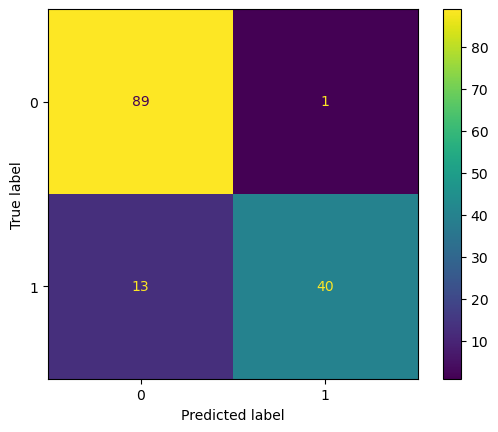

In [30]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

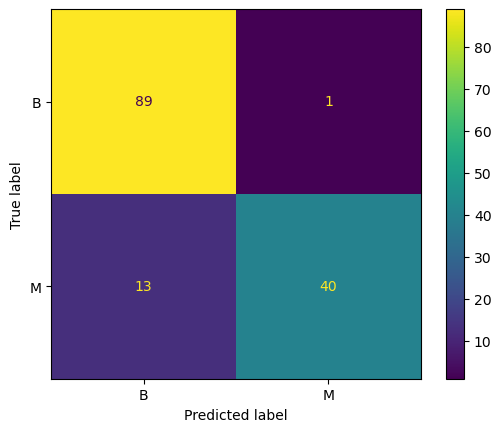

In [31]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

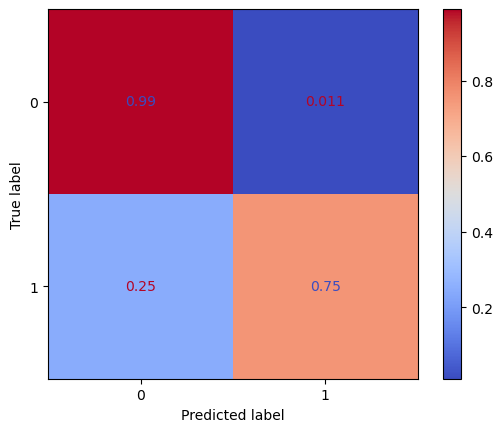

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true", cmap="coolwarm")